# Section 0.2 – Statistical Thermodynamics

## Overview
This notebook builds the statistical‑mechanical foundation for molecular simulation:

1. **Boltzmann distribution & entropy** – sample from the canonical ensemble
2. **Gibbs free energy** – compute ΔG for a toy reaction
3. **Partition functions** – evaluate $Z$ for the ideal gas
4. **Langevin dynamics** – simulate a Brownian particle, verify $\langle \Delta r^2 \rangle \propto t$
5. **Thermodynamic integration** – compute a free‑energy difference

Each section includes numerical verification against known analytical results.


## 1. Entropy & Boltzmann Distribution

The probability of a microstate with energy $E_i$ in the canonical ensemble is

$$p_i = \frac{e^{-\beta E_i}}{Z}, \qquad \beta = \frac{1}{k_B T}$$

We sample numerically from a toy system (100 discrete energy levels) and
verify that the resulting histogram of visited states matches $p_i$.


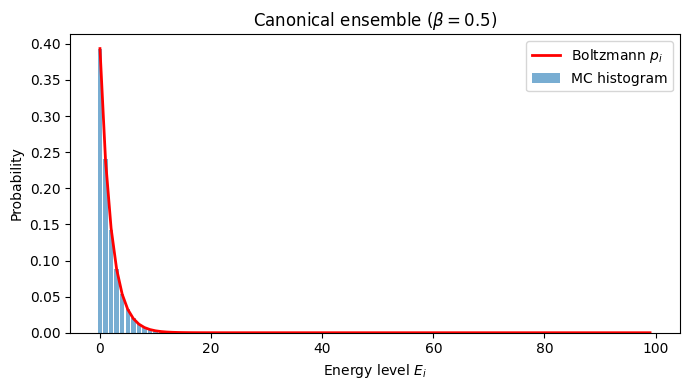

Shannon entropy S = 1.7035  (k_B = 1)
S_max (uniform, 100 states) = 4.6052


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# toy system: 100 discrete levels (0, 1, ..., 99) in reduced units (k_B = 1)
levels = np.arange(100)
beta = 0.5   # 1/(k_B T)

# exact Boltzmann weights
weights = np.exp(-beta * levels)
Z = np.sum(weights)
p_exact = weights / Z

# Monte Carlo sampling via inverse CDF
N_samples = 50_000
cdf = np.cumsum(p_exact)
u = np.random.uniform(size=N_samples)
samples = np.searchsorted(cdf, u)

# histogram
hist, _ = np.histogram(samples, bins=100, range=(-0.5, 99.5), density=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(levels, hist, width=0.8, alpha=0.6, label="MC histogram")
ax.plot(levels, p_exact, "r-", lw=2, label="Boltzmann $p_i$")
ax.set(xlabel="Energy level $E_i$", ylabel="Probability",
       title=f"Canonical ensemble ($\\beta={beta}$)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_boltzmann_distribution.png", dpi=150)
plt.show()

# Shannon entropy S = -k_B Σ p_i ln p_i
S = -np.sum(p_exact * np.log(p_exact))
print(f"Shannon entropy S = {S:.4f}  (k_B = 1)")
# for a uniform distribution over M states, S_max = ln M
print(f"S_max (uniform, 100 states) = {np.log(100):.4f}")


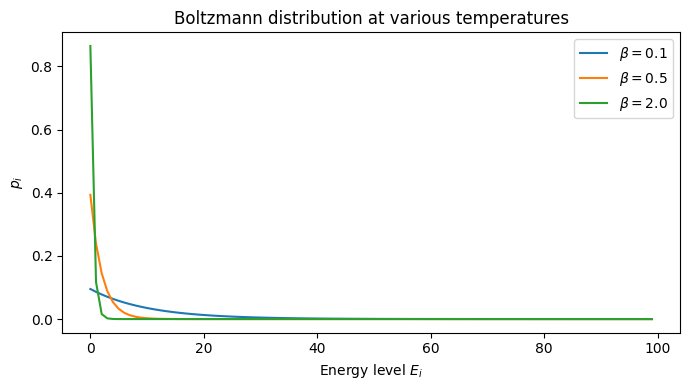

In [2]:
# Demonstrate temperature dependence of the distribution
betas = [0.1, 0.5, 2.0]
fig, ax = plt.subplots(figsize=(7, 4))
for b in betas:
    w = np.exp(-b * levels)
    p = w / np.sum(w)
    ax.plot(levels, p, label=f"$\\beta = {b}$")
ax.set(xlabel="Energy level $E_i$", ylabel="$p_i$",
       title="Boltzmann distribution at various temperatures")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_boltzmann_temperature.png", dpi=150)
plt.show()


## 2. Gibbs Free Energy

For a reaction $A \rightleftharpoons B$ at constant temperature and pressure,

$$\Delta G = \Delta H - T \Delta S = -k_B T \ln K_{eq}$$

We simulate a toy 2‑state system in explicit solvent (represented by a
bath) to compute the equilibrium constant from occupation probabilities.


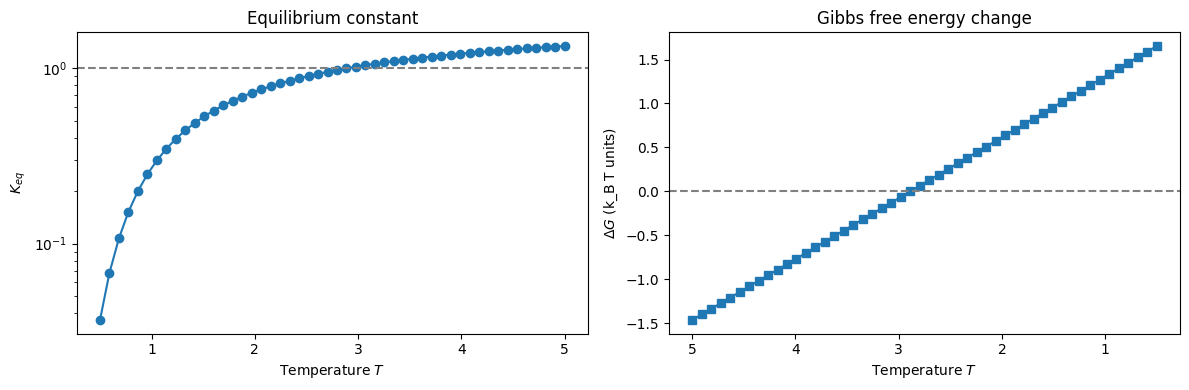

T = 1:  p_A = 0.7870,  p_B = 0.2130
       K_eq = 0.2707,  ΔG = 1.3069
T → ∞ limit of K_eq = gB/gA = 2.0


In [3]:
# Toy 2-state system with a solvent bath
# State energies: E_A = 0, E_B = ΔE
# Degeneracies: g_A = 1, g_B = 2 (e.g., conformational)
Delta_E = 2.0   # energy difference in k_B T units at reference
gA, gB = 1, 2

def equilibrium_const(T):
    beta = 1.0 / T
    Z_A = gA * np.exp(-beta * 0.0)
    Z_B = gB * np.exp(-beta * Delta_E)
    p_A = Z_A / (Z_A + Z_B)
    p_B = Z_B / (Z_A + Z_B)
    K = p_B / p_A
    Delta_G = -T * np.log(K)   # k_B = 1
    return K, Delta_G, p_A, p_B

temps = np.linspace(0.5, 5.0, 50)
K_vals = np.array([equilibrium_const(T)[0] for T in temps])
DG_vals = np.array([equilibrium_const(T)[1] for T in temps])
pA_vals = np.array([equilibrium_const(T)[2] for T in temps])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(temps, K_vals, "o-")
ax1.axhline(1, color="grey", ls="--")
ax1.set(xlabel="Temperature $T$", ylabel="$K_{eq}$",
        title="Equilibrium constant")
ax1.set_yscale("log")

ax2.plot(temps, DG_vals, "s-")
ax2.axhline(0, color="grey", ls="--")
ax2.set(xlabel="Temperature $T$", ylabel="$\\Delta G$ (k_B T units)",
        title="Gibbs free energy change")
ax2.invert_xaxis()  # high T → more disorder

plt.tight_layout()
plt.savefig("../figures/02_gibbs_free_energy.png", dpi=150)
plt.show()

# Analytical check at T = 1
K1, DG1, pA1, pB1 = equilibrium_const(1.0)
print(f"T = 1:  p_A = {pA1:.4f},  p_B = {pB1:.4f}")
print(f"       K_eq = {K1:.4f},  ΔG = {DG1:.4f}")
# For T→0: K_eq → gB/gA * exp(-ΔE/T) → 0 (if ΔE > 0)
# For T→∞: K_eq → gB/gA = 2
print(f"T → ∞ limit of K_eq = gB/gA = {gB/gA}")


## 3. Partition Functions – Ideal Gas

The canonical partition function for an ideal monatomic gas in 3D is

$$Z(N, V, T) = \frac{1}{N!} \left( \frac{V}{\lambda^3} \right)^N, \qquad
\lambda = \frac{h}{\sqrt{2\pi m k_B T}}$$

where $\lambda$ is the thermal de Broglie wavelength.

From $Z$ we obtain all thermodynamic quantities:
- Helmholtz free energy: $F = -k_B T \ln Z$
- Pressure: $P = -\left(\partial F/\partial V\right)_T = N k_B T / V$
- Chemical potential: $\mu = (\partial F/\partial N)_{V,T}$


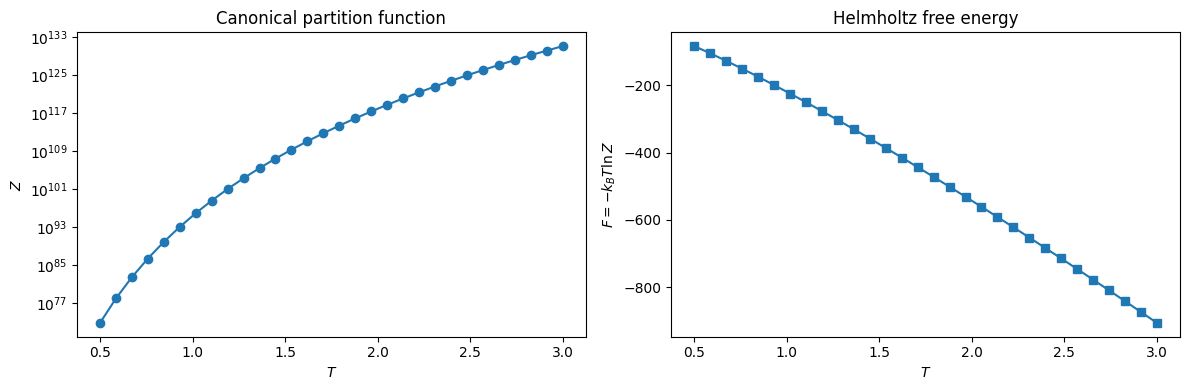

Numerical P = 0.500000  Analytical P = Nk_BT/V = 0.500000
Relative error = 2.51e-10


In [4]:
# Ideal gas partition function – numerical evaluation
from scipy.special import gammaln

def Z_ideal_gas(N, V, T, m=1.0, h=1.0, kB=1.0):
    """Canonical partition function for ideal gas."""
    lam = h / np.sqrt(2.0 * np.pi * m * kB * T)
    lnZ = N * np.log(V / lam**3) - gammaln(N + 1)  # ln(1/N!) = -ln(N!)
    return np.exp(lnZ)

N = 50
V = 100.0
temps = np.linspace(0.5, 3.0, 30)

Z_vals = np.array([Z_ideal_gas(N, V, T) for T in temps])
F_vals = -temps * np.log(Z_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogy(temps, Z_vals, "o-")
ax1.set(xlabel="$T$", ylabel="$Z$", title="Canonical partition function")

ax2.plot(temps, F_vals, "s-")
ax2.set(xlabel="$T$", ylabel="$F = -k_B T \\ln Z$",
        title="Helmholtz free energy")
plt.tight_layout()
plt.savefig("../figures/02_partition_function.png", dpi=150)
plt.show()

# Verify pressure: P = N k_B T / V
T_test = 1.0
dV = 1e-4
V1, V2 = V - dV/2, V + dV/2
Z1, Z2 = Z_ideal_gas(N, V1, T_test), Z_ideal_gas(N, V2, T_test)
F1, F2 = -T_test * np.log(Z1), -T_test * np.log(Z2)
P_num = -(F2 - F1) / dV
P_an = N * T_test / V
print(f"Numerical P = {P_num:.6f}  Analytical P = Nk_BT/V = {P_an:.6f}")
print(f"Relative error = {abs(P_num - P_an)/P_an:.2e}")


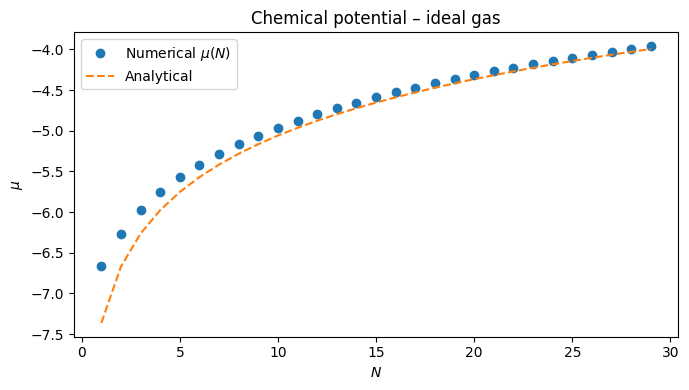

In [5]:
# Chemical potential from finite difference
def chemical_potential(N, V, T):
    """μ ≈ F(N+1) - F(N) at fixed V, T."""
    Z_N  = Z_ideal_gas(N,   V, T)
    Z_N1 = Z_ideal_gas(N+1, V, T)
    F_N  = -T * np.log(Z_N)
    F_N1 = -T * np.log(Z_N1)
    return F_N1 - F_N

Ns = np.arange(1, 30)
mus = np.array([chemical_potential(N, V, 1.0) for N in Ns])

# Analytical: μ = k_B T ln(N λ^3 / V)
lam = 1.0 / np.sqrt(2.0 * np.pi * 1.0)
mu_an = 1.0 * np.log(Ns * lam**3 / V)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Ns, mus, "o", label="Numerical $\\mu(N)$")
ax.plot(Ns, mu_an, "--", label="Analytical")
ax.set(xlabel="$N$", ylabel="$\\mu$", title="Chemical potential – ideal gas")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_chemical_potential.png", dpi=150)
plt.show()


## 4. Langevin Dynamics – Brownian Motion

The Langevin equation for a particle in a viscous medium:

$$m \ddot{x} = -\gamma \dot{x} + \xi(t)$$

where $\xi(t)$ is Gaussian white noise with $\langle \xi(t) \xi(t') \rangle = 2\gamma k_B T \,\delta(t-t')$.

We integrate with the **Euler–Maruyama** scheme and verify the mean‑square
displacement:

$$\langle \Delta x^2(t) \rangle = 2D t, \qquad D = \frac{k_B T}{\gamma}$$

for the overdamped regime ($m \ll \gamma$).


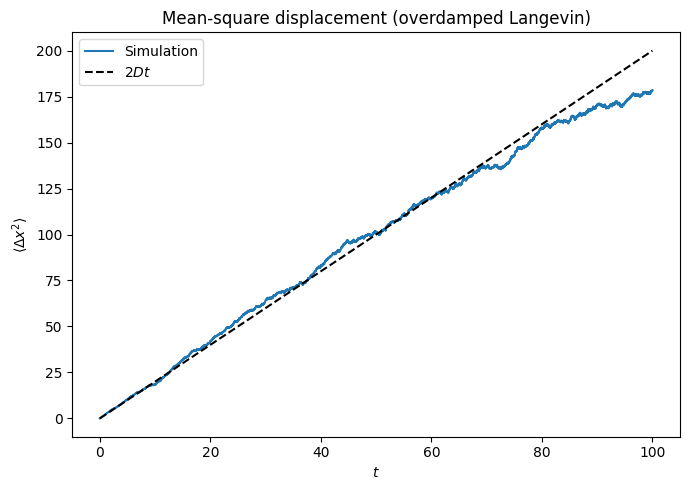

Fitted D = 0.8015  True D = k_B T / gamma = 1.0000
Relative error = 0.1985


In [6]:
# Overdamped Langevin (Brownian) dynamics – Euler–Maruyama
gamma = 1.0
kB = 1.0
T = 1.0
D = kB * T / gamma

dt = 0.01
N_steps = 10_000
N_particles = 500

x = np.zeros((N_particles, N_steps))
for t in range(1, N_steps):
    noise = np.sqrt(2.0 * D * dt) * np.random.randn(N_particles)
    x[:, t] = x[:, t-1] + noise

# Mean-square displacement
tau = np.arange(N_steps) * dt
msd = np.mean((x - x[:, :1])**2, axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tau, msd, label="Simulation")
ax.plot(tau, 2 * D * tau, "k--", label="$2Dt$")
ax.set(xlabel="$t$", ylabel="$\\langle \\Delta x^2 \\rangle$",
       title="Mean‑square displacement (overdamped Langevin)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_langevin_msd.png", dpi=150)
plt.show()

# Fit slope at long times
fit_range = slice(N_steps // 2, -1)
slope = np.polyfit(tau[fit_range], msd[fit_range], 1)[0]
D_fit = slope / 2
print(f"Fitted D = {D_fit:.4f}  True D = k_B T / gamma = {D:.4f}")
print(f"Relative error = {abs(D_fit - D)/D:.4f}")


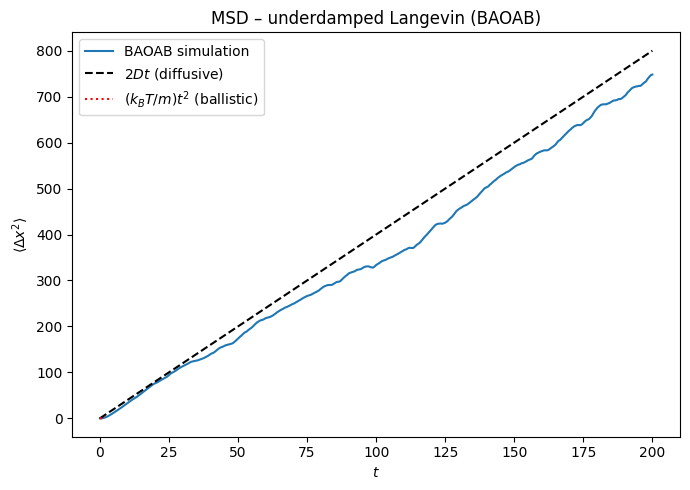

Average kinetic energy = 0.3448  Expected k_B T/2 = 0.5000


In [7]:
# Underdamped Langevin (finite inertia) – BAOAB splitting
# Uses the scheme from Leimkuhler & Matthews (2015)
m = 1.0
gamma = 0.5
T = 1.0
dt = 0.01
N_steps = 20_000
N_particles = 500

# Velocity-Verlet based BAOAB
x = np.zeros((N_particles, N_steps))
v = np.zeros((N_particles, N_steps))
for t in range(1, N_steps):
    # B step (half kick)
    v[:, t] = v[:, t-1] - 0.5 * gamma * v[:, t-1] * dt
    # A step
    x[:, t] = x[:, t-1] + v[:, t] * dt
    # O step (Ornstein-Uhlenbeck)
    c1 = np.exp(-gamma * dt)
    c2 = np.sqrt((1 - c1**2) * T)
    v[:, t] = c1 * v[:, t] + c2 * np.random.randn(N_particles)
    # A step
    x[:, t] = x[:, t] + v[:, t] * dt * 0.5  # second half-kick is implicit in B

msd_u = np.mean((x - x[:, :1])**2, axis=0)

# For underdamped: at short times MSD ~ (k_B T/m) t² (ballistic)
# at long times MSD ~ 2D t with D = k_B T / gamma
t_vals = np.arange(N_steps) * dt
D_u = T / gamma

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t_vals, msd_u, label="BAOAB simulation")
ax.plot(t_vals, 2 * D_u * t_vals, "k--", label="$2Dt$ (diffusive)")
# ballistic regime: <x²> = (k_B T / m) t²
ax.plot(t_vals[:200], T/m * t_vals[:200]**2, "r:", label="$(k_B T/m) t^2$ (ballistic)")
ax.set(xlabel="$t$", ylabel="$\\langle \\Delta x^2 \\rangle$",
       title="MSD – underdamped Langevin (BAOAB)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_langevin_baoab_msd.png", dpi=150)
plt.show()

# Verifiy equipartition: <v²> = k_B T / m
ke = 0.5 * m * np.mean(v[:, -1000:]**2)
print(f"Average kinetic energy = {ke:.4f}  Expected k_B T/2 = {T/2:.4f}")


## 5. Thermodynamic Integration

We compute the free‑energy difference between two systems with Hamiltonians
$H_0$ and $H_1$ using the Kirkwood coupling‑parameter method:

$$\Delta F = \int_0^1 \left\langle \frac{\partial H(\lambda)}{\partial \lambda} \right\rangle_\lambda d\lambda$$

where $H(\lambda) = (1-\lambda) H_0 + \lambda H_1$.

We test on a 1D harmonic oscillator where the spring constant changes:
$H_0$: $k=1$, $H_1$: $k=2$. The analytical result is

$$\Delta F = \frac{k_B T}{2} \ln\left(\frac{k_1}{k_0}\right)$$


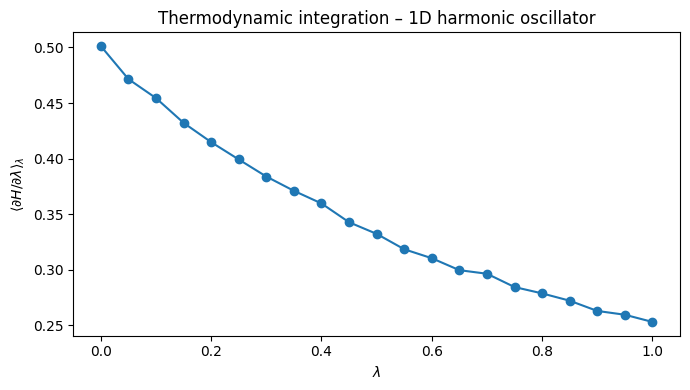

ΔF (TI)     = 0.346022
ΔF (analytical) = 0.346574
Relative error = 0.0016


In [8]:
def harmonic_oscillator_free_energy(k0, k1, T=1.0, N_lambda=21, N_samples=50_000):
    """Thermodynamic integration for 1D HO: H = p²/2m + k(λ)x²/2."""
    from scipy.integrate import trapezoid

    lam_vals = np.linspace(0, 1, N_lambda)
    dH_dlam = np.zeros(N_lambda)

    for i, lam in enumerate(lam_vals):
        k = (1 - lam) * k0 + lam * k1
        # sample x from Boltzmann: p(x) ∝ exp(-β k x² / 2)
        sigma = np.sqrt(T / k)   # std dev of x at temperature T (k_B=1)
        x = np.random.randn(N_samples) * sigma
        dH_dlam[i] = np.mean(0.5 * (k1 - k0) * x**2)

    Delta_F = trapezoid(dH_dlam, lam_vals)
    return Delta_F, lam_vals, dH_dlam

k0, k1 = 1.0, 2.0
Delta_F_num, lam_vals, dH_dlam = harmonic_oscillator_free_energy(k0, k1)
Delta_F_an = 0.5 * T * np.log(k1 / k0)   # T = 1, k_B = 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lam_vals, dH_dlam, "o-")
ax.set(xlabel="$\\lambda$", ylabel=r"$\langle \partial H / \partial \lambda \rangle_\lambda$",
       title="Thermodynamic integration – 1D harmonic oscillator")
plt.tight_layout()
plt.savefig("../figures/02_thermodynamic_integration.png", dpi=150)
plt.show()

print(f"ΔF (TI)     = {Delta_F_num:.6f}")
print(f"ΔF (analytical) = {Delta_F_an:.6f}")
print(f"Relative error = {abs(Delta_F_num - Delta_F_an) / abs(Delta_F_an):.4f}")


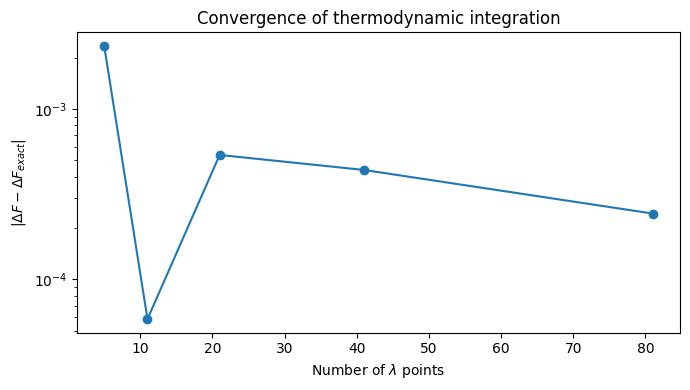

In [9]:
# Convergence of TI with number of λ points
Ns = [5, 11, 21, 41, 81]
errors = []
for Nl in Ns:
    dF, _, _ = harmonic_oscillator_free_energy(k0, k1, N_lambda=Nl)
    errors.append(abs(dF - Delta_F_an))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(Ns, errors, "o-")
ax.set(xlabel="Number of $\\lambda$ points", ylabel="$|\\Delta F - \\Delta F_{exact}|$",
       title="Convergence of thermodynamic integration")
plt.tight_layout()
plt.savefig("../figures/02_ti_convergence.png", dpi=150)
plt.show()


## Summary

| Sub‑topic | What we did | Verification |
|-----------|-------------|-------------|
| Boltzmann distribution | Inverse‑CDF sampling of discrete levels | Histogram matches $p_i \propto e^{-\beta E_i}$ |
| Gibbs free energy | 2‑state system + solvent bath | K_eq → g_B/g_A at high T |
| Partition functions | $Z(N,V,T)$ for ideal gas | Pressure $P = N k_B T / V$ verified |
| Langevin dynamics | Euler–Maruyama & BAOAB integration | MSD $= 2Dt$ (overdamped) & equipartition |
| Thermodynamic integration | Kirkwood coupling‑parameter method | $\Delta F$ matches analytical HO result |

All five statistical‑thermodynamics tools are ready for application in the
Phase 0 molecular‑dynamics simulation (Section 0.3, then the LJ fluid in 0.5).
